# 01 · AeroSandbox's symbolic NumPy: one function for numbers and for optimization variables

Every physics function in this repository is written once and called in two ways:

- with **numbers**, to evaluate a design (unit tests, post-processing, plots);
- with **CasADi symbols** (optimization variables, or expressions built from them), to contribute equations to an
  `asb.Opti` problem, with exact derivatives.

What makes this possible is `aerosandbox.numpy`, imported everywhere as `np`. This notebook shows how it works, what it
gives you (exact, sparse derivatives through any amount of physics) and the handful of Python habits that silently
break it. The project's coding rules forbid exactly these habits (`docs/CODING_CONVENTIONS.md`, "Symbolic math").

**In this notebook**
1. Numbers in, numbers out; symbols in, expression graphs out.
2. What a CasADi expression is, and how to evaluate and differentiate it outside an optimizer.
3. Exact derivatives versus finite differences.
4. Five things that break a symbolic function, and the replacements the code uses.
5. The AeroSandbox pieces the repository leans on: units, `Atmosphere`, `MassProperties`, `InterpolatedModel`.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp          # plain NumPy, named onp to keep it apart from aerosandbox.numpy (np)
import casadi as cas

## 1. Numbers in, numbers out; symbols in, graphs out

Take ideal hover power from momentum theory, divided by a figure of merit:
$P = T^{3/2} / \sqrt{2 \rho A} \,/\, \mathrm{FM}$.

In [2]:
def hover_power_W(thrust_N, area_disk_m2, density_kg_m3=1.225, figure_of_merit=0.7):
    return thrust_N**1.5 / np.sqrt(2 * density_kg_m3 * area_disk_m2) / figure_of_merit

print("float in   ->", hover_power_W(20000.0, 20.0))
print("array in   ->", hover_power_W(onp.array([10000.0, 20000.0]), 20.0))

opti = asb.Opti()
area_m2 = opti.variable(init_guess=20.0)
expression = hover_power_W(20000.0, area_m2)
print("variable in ->", type(area_m2).__name__, "->", type(expression).__name__)
print("the graph   :", expression)

float in   -> 577230.0254584062
array in   -> [204081.63265306 577230.02545841]
variable in -> MX -> MX
the graph   : ((2.82843e+06/sqrt((49*opti0_x_1)))/0.7)


`np.sqrt` looked at its argument: a float went to NumPy, a CasADi `MX` symbol went to `casadi.sqrt`. Every function in
`aerosandbox.numpy` does this dispatch (`sqrt`, `exp`, `log`, `sin`, `cosd`, `softmax`, `where`, `sum`, `linspace`...). The
operators `+ - * / **` are overloaded by CasADi itself, so plain arithmetic works too.

`MX` is CasADi's *matrix expression* type. An Opti variable is a leaf; every operation adds a node. Nothing is
computed: `expression` is a recipe. This is what every `evaluate(...)` in `src/` returns when the sizing passes it
variables.

## 2. Evaluating and differentiating an expression without solving

You rarely need this in practice (the optimizer does it), but it makes the machinery concrete. A `casadi.Function` turns
the graph into a callable, and `cas.jacobian` builds the derivative graph symbolically.

One detail: an AeroSandbox Opti variable is not a bare CasADi symbol but `scale x (underlying symbol)`, an expression
(tutorial 02 explains the scaling). `casadi.Function` needs bare symbols as inputs, so for this demonstration we use a
raw `cas.MX.sym`:

In [3]:
area_sym_m2 = cas.MX.sym("area_m2")
expression_raw = hover_power_W(20000.0, area_sym_m2)
power_of_area = cas.Function("power_of_area", [area_sym_m2], [expression_raw])
derivative = cas.Function("dP_dA", [area_sym_m2], [cas.jacobian(expression_raw, area_sym_m2)])
print("the Opti variable itself is an expression:", area_m2)
print(f"P(20 m2)     = {float(power_of_area(20.0)):,.1f} W")
print(f"dP/dA(20 m2) = {float(derivative(20.0)):,.3f} W/m2  (exact, from the graph)")

# Analytic: P ~ A^(-1/2) so dP/dA = -P / (2 A)
check("CasADi's derivative equals the analytic -P/(2A)",
      abs(float(derivative(20.0)) - (-float(power_of_area(20.0)) / (2 * 20.0))) < 1e-9)

the Opti variable itself is an expression: (20*opti0_x_1)
P(20 m2)     = 577,230.0 W
dP/dA(20 m2) = -14,430.751 W/m2  (exact, from the graph)
PASS  CasADi's derivative equals the analytic -P/(2A)


Inside an Opti problem, `opti.value(expr)` evaluates any expression at the current iterate, and after a solve
`solution.value(expr)` evaluates it at the optimum, including expressions you never constrained (that is how every
result dataclass in the repository is filled). Tutorial 02 covers that.

## 3. Why exact derivatives matter: AD versus finite differences

Finite differences carry truncation error (step too large) and round-off error (step too small). Automatic
differentiation has neither: it applies the chain rule to the graph exactly. Here is the error of a forward
difference on the derivative above, as a function of the step:

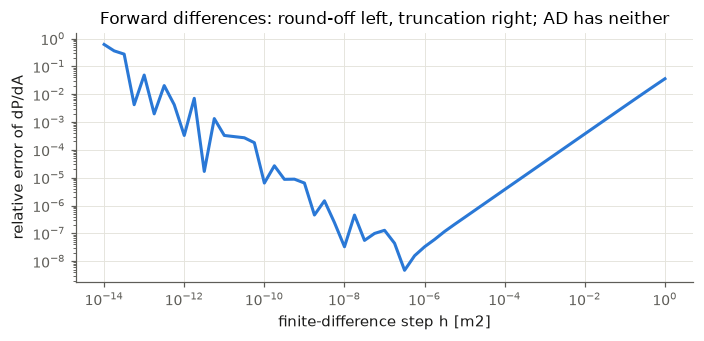

best forward-difference relative error: 4.7e-09 (AD: exact to machine precision)


In [4]:
exact = float(derivative(20.0))
steps = onp.logspace(-14, 0, 57)
errors = [abs((hover_power_W(20000.0, 20.0 + h) - hover_power_W(20000.0, 20.0)) / h - exact) / abs(exact) for h in steps]

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.loglog(steps, errors, color=blue, lw=2)
ax.set(xlabel="finite-difference step h [m2]", ylabel="relative error of dP/dA",
       title="Forward differences: round-off left, truncation right; AD has neither")
plt.tight_layout(); plt.show()
print(f"best forward-difference relative error: {min(errors):.1e} (AD: exact to machine precision)")

The Halo problem has a few hundred variables and about a thousand constraints, and IPOPT also uses **second**
derivatives (the Hessian of the Lagrangian). With finite differences that would be thousands of extra function
evaluations per iteration, and noisy. CasADi builds sparse first and second derivatives once, symbolically. This is
one of the main reasons the code is written as explicit expressions instead of calling black-box analyses.

## 4. Five things that break a symbolic function

Each either raises an error or, worse, quietly does the wrong thing when the argument is a symbol. Each one is listed
in `docs/CODING_CONVENTIONS.md`, and you will see the replacements throughout `src/`.

In [5]:
x = opti.variable(init_guess=1.0)

def attempt(label, function):
    try:
        out = function()
        print(f"ran      {label}  ->  {type(out).__name__}")
    except Exception as error:
        print(f"FAILS    {label}\n         {type(error).__name__}: {str(error).splitlines()[0][:110]}")

attempt("1. float(symbol)", lambda: float(x))
attempt("2. if symbol > 0: ...", lambda: (1.0 if x > 0 else -1.0))
attempt("3a. plain numpy on a symbol: onp.exp(x)", lambda: onp.exp(x))
attempt("3b. plain numpy on a symbol: onp.sort([x, 1.0])", lambda: onp.sort([x, 1.0]))
print("3c. onp.interp(x, ...) 'works', but look at what it built (piecewise, with kinks and switches):")
print("   ", onp.interp(x, [0.0, 1.0], [0.0, 2.0]))
attempt("4. math module: math.sqrt(x)", lambda: __import__("math").sqrt(x))
attempt("5. Python max() of symbols", lambda: max(x, 0.0))

FAILS    1. float(symbol)
         RuntimeError: .../casadi/core/mx_node.cpp:480: 'to_double' not defined for class N6casadi10SymbolicMXE
FAILS    2. if symbol > 0: ...
         RuntimeError: .../casadi/core/mx_node.cpp:205: Can only determine truth value of a numeric MX.
ran      3a. plain numpy on a symbol: onp.exp(x)  ->  MX
FAILS    3b. plain numpy on a symbol: onp.sort([x, 1.0])
         RuntimeError: .../casadi/core/mx_node.cpp:205: Can only determine truth value of a numeric MX.
3c. onp.interp(x, ...) 'works', but look at what it built (piecewise, with kinks and switches):
    @1=(opti0_x_2<1), ((!(opti0_x_2<0))?((@1?(2.*opti0_x_2):0)+((!@1)?2:0)):0)
FAILS    4. math module: math.sqrt(x)
         RuntimeError: .../casadi/core/mx_node.cpp:480: 'to_double' not defined for class N6casadi10SymbolicMXE
FAILS    5. Python max() of symbols
         RuntimeError: .../casadi/core/mx_node.cpp:205: Can only determine truth value of a numeric MX.


What each failure means, and what the code does instead:

| Habit | Why it breaks | What the code uses |
|---|---|---|
| `float(expr)` | a symbol has no value until the solve | keep expressions symbolic; convert only after the solve: `float(solution.value(expr))` (every `examples/` driver does this in one place, at the end) |
| `if expr > 0:` | the comparison builds a *symbolic* boolean; Python cannot branch on it (in some cases it branches on the wrong thing silently) | smooth formulas, or `np.where(cond, a, b)` (both branches stay in the graph, so both must be finite) |
| `onp.exp(x)` | works *by accident* in this CasADi version (a legacy hook forwards some NumPy ufuncs, with a `FutureWarning` the helpers silence), but fails for anything that needs a numeric comparison (`onp.sort`), and `onp.interp` quietly builds a non-smooth switch graph | `aerosandbox.numpy` (`np.exp`, and `asb.InterpolatedModel` for tables) |
| `math.sqrt(x)` | same | `np.sqrt` |
| `max(x, 0)` | Python compares symbols | `np.fmax` / `np.maximum` (exact but kinked), or `np.softmax(a, b, softness=s)` (smooth) |

**Branching on a Python setting is fine.** The code branches constantly on *model switches* that are plain Python values,
for example `if self.airplane_mode:` in the rotor or `if self.mass_model is not None:` in the motor. The rule is only that
you never branch on something that might be a symbol. You will see helper functions such as
`_is_value(setting, 1.0)` in `aerodynamics/buildup.py` whose only job is to make that distinction explicit.

### The kink problem, concretely

`np.maximum` works on symbols, but its derivative jumps at the kink. A Newton method that lands near a kink chatters.
`np.softmax(a, b, softness=s)` is $s \ln(e^{a/s} + e^{b/s})$: smooth everywhere, never below the true max, and at most
$s \ln 2$ above it. The code picks `s` small against the quantity and documents it next to the call. Two examples
from `src/`:

In [6]:
import inspect
from aircraft_closure.powertrain.components.motor import TorqueDensityMassModel
from aircraft_closure.powertrain.components.battery import Battery
print(inspect.getsource(TorqueDensityMassModel.mass_kg))
print(inspect.getsource(Battery.get_mass))

    def mass_kg(self, machine):
        return np.softmax(machine.max_torque_Nm / self.torque_density_Nm_kg,
                          machine.power_rated_W / self.specific_power_max_W_kg, softness=self.smoothing_kg)

    def get_mass(self):
        # Energy capacity alone can undersize a hover pack: both charge and
        # discharge ratings must be supported by the installed pack mass.
        mass_energy_kg = self.energy_capacity_J / self.specific_energy_J_kg
        mass_power_kg = np.maximum(self.max_discharge_power_W, self.max_charge_power_W) / self.specific_power_W_kg
        if self.mass_smoothing_kg is None:
            return np.maximum(mass_energy_kg, mass_power_kg)
        # Optional smooth maximum for optimizers that size energy and power
        # together; it overestimates the exact maximum by at most smoothing x ln 2.
        return np.softmax(mass_energy_kg, mass_power_kg, softness=self.mass_smoothing_kg)



The machine mass is the larger of a torque-limited and a power-limited mass, smoothed by 2 kg. The battery mass is the
larger of an energy-sized and a power-sized mass: exact `np.maximum` by default (fine when the battery is not sized),
and a softmax when the caller sizes energy and power together (`mass_smoothing_kg`).

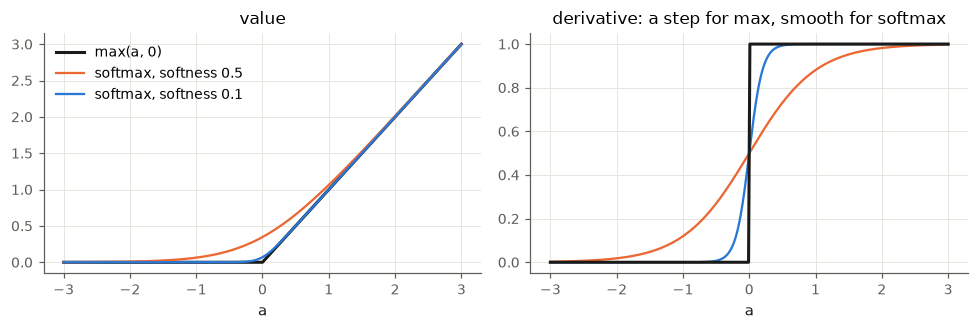

PASS  softmax never undershoots and overshoots by at most softness x ln 2


In [7]:
a = onp.linspace(-3, 3, 601)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.1))
axes[0].plot(a, onp.maximum(a, 0), color=ink, lw=2, label="max(a, 0)")
for softness, color in ((0.5, orange), (0.1, blue)):
    smooth = np.softmax(a, 0 * a, softness=softness)
    axes[0].plot(a, smooth, color=color, lw=1.5, label=f"softmax, softness {softness}")
    axes[1].plot(a, onp.gradient(smooth, a), color=color, lw=1.5)
axes[1].plot(a, onp.gradient(onp.maximum(a, 0), a), color=ink, lw=2)
axes[0].set(title="value", xlabel="a"); axes[1].set(title="derivative: a step for max, smooth for softmax", xlabel="a")
axes[0].legend(); plt.tight_layout(); plt.show()
check("softmax never undershoots and overshoots by at most softness x ln 2",
      onp.all(np.softmax(a, 0 * a, softness=0.1) >= onp.maximum(a, 0))
      and onp.max(np.softmax(a, 0 * a, softness=0.1) - onp.maximum(a, 0)) <= 0.1 * onp.log(2) + 1e-12)

`np.where` deserves a warning: both branches are evaluated. `np.where(x > 0, np.sqrt(x), 0)` produces a NaN derivative at
negative `x` because `sqrt` of a negative number is still in the graph. The actuator-disk propulsor shows the safe pattern:
it protects only the exact removable singularity, `np.where(denominator == 0, 1, denominator)`, so neither branch can be
undefined.

## 5. The AeroSandbox pieces the code leans on

### Units

The code is SI internally and every dimensional name carries its unit (`velocity_m_s`, `power_rated_W`). Inputs in other
units are converted at the boundary with `aerosandbox.tools.units` (imported as `u`), whose constants are the SI value of
one unit:

In [8]:
print(f"210 kt          = {210 * u.knot:.2f} m/s")
print(f"10,000 ft       = {10000 * u.foot:.1f} m")
print(f"1,120 hp        = {1120 * u.hp / 1e3:.1f} kW")
print(f"2,500 rpm       = {2500 * u.rpm:.1f} rad/s")
print(f"15,179 lb       = {15179 * u.lbm:.0f} kg")
print(f"6.25 ft2 (D/q)  = {6.25 * u.foot**2:.3f} m2")
# Reading results back: divide by the unit.
print(f"88 m/s          = {88 / u.knot:.1f} kt")

210 kt          = 108.03 m/s
10,000 ft       = 3048.0 m
1,120 hp        = 835.2 kW
2,500 rpm       = 261.8 rad/s
15,179 lb       = 6885 kg
6.25 ft2 (D/q)  = 0.581 m2
88 m/s          = 171.1 kt


### The atmosphere

`asb.Atmosphere(altitude=..., temperature_deviation=...)` is the ISA model, differentiable in altitude (so altitude can be
a design variable, see the "free cruise altitude" trade in the driver). `temperature_deviation` is the hot-day offset in
kelvin at the same pressure altitude, which is how the 95 °F hover is modelled:

In [9]:
for altitude_ft, offset_K, label in ((0, 0.0, "sea level ISA"), (4000, 0.0, "4,000 ft ISA"),
                                     (4000, (95 - 32) * 5 / 9 + 273.15 - asb.Atmosphere(4000 * u.foot).temperature(), "4,000 ft, 95 F"),
                                     (10000, 0.0, "10,000 ft ISA")):
    atmosphere = asb.Atmosphere(altitude=altitude_ft * u.foot, temperature_deviation=offset_K)
    print(f"{label:<16} rho {atmosphere.density():.4f} kg/m3   T {atmosphere.temperature() - 273.15:6.1f} C   "
          f"a {atmosphere.speed_of_sound():6.1f} m/s   sigma {atmosphere.density() / 1.225:.3f}")

h = opti.variable(init_guess=3000.0)
print("\nsymbolic altitude ->", type(asb.Atmosphere(altitude=h).density()).__name__)

sea level ISA    rho 1.2250 kg/m3   T   15.0 C   a  340.3 m/s   sigma 1.000
4,000 ft ISA     rho 1.0869 kg/m3   T    7.3 C   a  335.7 m/s   sigma 0.887
4,000 ft, 95 F   rho 0.9893 kg/m3   T   35.0 C   a  351.9 m/s   sigma 0.808
10,000 ft ISA    rho 0.9028 kg/m3   T   -4.3 C   a  328.7 m/s   sigma 0.737

symbolic altitude -> MX


### Mass properties

`asb.MassProperties(mass=..., x_cg=..., z_cg=...)` objects add with `+`, and the sum's CG is the mass-weighted mean. The
whole aircraft mass and CG in `vehicle/aircraft.py` is one such sum (tutorial 12), and it works on symbols:

In [10]:
wing = asb.MassProperties(mass=600.0, x_cg=4.0)
engine = asb.MassProperties(mass=400.0, x_cg=6.0)
total = wing + engine
print(f"total {total.mass:.0f} kg at x_cg {total.x_cg:.2f} m")
check("MassProperties addition gives the mass-weighted CG", abs(total.x_cg - (600 * 4 + 400 * 6) / 1000) < 1e-12)
m = opti.variable(init_guess=500.0)
print("symbolic:", type((wing + asb.MassProperties(mass=m, x_cg=6.0)).x_cg).__name__)

total 1000 kg at x_cg 4.80 m
PASS  MassProperties addition gives the mass-weighted CG
symbolic: MX


### Interpolated tables

Tabulated data enters the graph through `asb.InterpolatedModel` with `method="bspline"`, a smooth spline CasADi can
differentiate (`TabulatedOcvModel` in the battery, `TabulatedPartPowerModel` in the turboshaft). The code generally prefers a
fitted polynomial where the table is steep: a B-spline through the steep low-power end of the engine deck stalled IPOPT
for thousands of iterations, so the reference uses a fitted cubic (`docs/decisions/014`). Tutorial 06 shows both.

In [11]:
table = asb.InterpolatedModel(x_data_coordinates=onp.array([0.0, 0.25, 0.5, 0.75, 1.0]),
                              y_data_structured=onp.array([3.0, 3.5, 3.65, 3.85, 4.15]), method="bspline")
print("numeric :", table(0.6))
print("symbolic:", type(table(opti.variable(init_guess=0.5))).__name__)

numeric : 3.715600000000001
symbolic: MX


## Summary

- `aerosandbox.numpy` dispatches every call: numbers go to NumPy, symbols go to CasADi. Write physics once with `np`.
- A symbolic result is an expression graph; CasADi differentiates it exactly (first and second derivatives, sparse).
- Never `float()`, never `if` on, never plain-NumPy a value that might be a symbol. Branch only on Python settings.
- Kinks (`max`, `abs`, steps) are replaced by smooth functions with a stated, small error.
- Units are converted at the boundary; the atmosphere, mass properties and spline tables are all differentiable.

## Check yourself

<details><summary>1. A colleague writes <code>if speed_rad_s > speed_limit: speed_rad_s = speed_limit</code> inside a motor model. What goes wrong, and what is the right design?</summary>

When `speed_rad_s` is a variable the comparison is symbolic and the branch is wrong or an error. Clipping inside a component is also forbidden by design: it hides a limit from the optimizer and makes the function non-smooth. The component should return the speed unchanged and expose the limit through `get_limits()`; the caller constrains `speed <= max_speed` (as a normalized margin).
</details>

<details><summary>2. Why does <code>np.where(x > 0, np.log(x), 0)</code> give NaN gradients?</summary>

Both branches stay in the graph. At negative `x` the derivative of `log(x)` is evaluated and is NaN, which pollutes the gradient even though the branch is not selected.
</details>

<details><summary>3. Which branches in <code>MomentumProfileRotor.evaluate</code> are legal?</summary>

`if self.airplane_mode:`, because `airplane_mode` is a Python `bool` field set when the model is built. The rotor never branches on thrust, speed or density, which may be symbols.
</details>

In [12]:
check_summary()

3 of 3 checks passed
